# 1. Jet 이란 무엇인가 — 직접 확인하기

이 노트북의 목적은 하나다. **jet 이 무엇인지 정의로 외우는 대신 눈으로 보는 것.**

순서:

1. ROOT 파일을 열고 안에 무엇이 있는지 본다
2. 한 이벤트의 입자들을 평면에 찍어본다 → **뭉쳐 있는 게 보인다**
3. 그 뭉침을 알고리즘으로 찾아낸다 (= 클러스터링) → 그게 jet 이다
4. jet 하나를 열어서 어떤 입자들로 이루어졌는지 확인한다
5. 여러 이벤트를 모아 jet 의 성질을 본다

**필요한 설치** (한 번만):

```
pip install uproot awkward vector fastjet matplotlib numpy
```

**필요한 데이터**: `python src/make_sample.py` 를 먼저 실행하면
`data/raw/sample_events.root` 가 만들어진다.

> ⚠️ 이 노트북이 쓰는 것은 **실제 충돌 데이터가 아니라 흉내낸 샘플**이다.
> 코드와 개념을 익히는 용도다. 진짜 Open Data 로 바꾸는 방법은 마지막 절에 있다.

## 0. 준비

In [1]:
import pathlib

import awkward as ak
import fastjet
import matplotlib.pyplot as plt
import numpy as np
import uproot
import vector

# awkward 배열에서 4-벡터 연산(pt, eta, phi, 질량 등)을 쓸 수 있게 등록한다
vector.register_awkward()

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
DATA = REPO / "data" / "raw" / "sample_events.root"

print("데이터 파일:", DATA)
print("존재함:", DATA.exists())

데이터 파일: /sessions/stoic-wizardly-fermi/mnt/Jet_analysis/data/raw/sample_events.root
존재함: True


## 1. ROOT 파일 안에는 무엇이 있나

입자물리 데이터는 거의 다 **ROOT 파일**(`.root`)에 들어있다. 표(table)라고 생각하면 된다.
다만 칸 하나에 숫자 하나가 아니라 **숫자 목록**이 들어갈 수 있다는 게 다르다.

왜냐면 이벤트(=양성자 충돌 한 번)마다 튀어나온 입자 수가 다르기 때문이다.
어떤 이벤트는 50개, 어떤 이벤트는 300개. 그래서 "이벤트당 입자 pT 목록" 같은 형태가 된다.

`uproot` 로 열어보자. ROOT 프로그램을 설치할 필요 없이 파이썬만으로 읽힌다.

In [2]:
f = uproot.open(DATA)

# 파일 안에 들어있는 것들 (보통 TTree 하나)
print("파일 안의 객체:", f.keys())

파일 안의 객체: ['Events;1']


In [3]:
tree = f["Events"]

print("이벤트 수:", tree.num_entries)
print()
print("들어있는 변수(branch):")
for name in tree.keys():
    print(f"  {name:20s}  {tree[name].typename}")

이벤트 수: 200

들어있는 변수(branch):
  Particle_eta          std::vector<double>
  Particle_mass         std::vector<double>
  Particle_phi          std::vector<double>
  Particle_pt           std::vector<double>


`float[]` 처럼 대괄호가 붙은 게 "목록"이라는 뜻이다. 이벤트마다 길이가 다르다.

변수 이름의 의미:

| 변수 | 뜻 |
|---|---|
| `Particle_pt` | 횡운동량 — 빔 방향에 **수직인** 운동량 크기 [GeV] |
| `Particle_eta` | 유사래피디티 — 빔축에서 얼마나 벌어졌나 (0이면 빔에 수직, 크면 빔 방향) |
| `Particle_phi` | 방위각 — 빔축을 중심으로 돌아간 각도 [rad, −π~π] |
| `Particle_mass` | 질량 [GeV] |

`pT` 를 쓰는 이유: 충돌 전 양성자는 빔 방향으로만 움직이므로 **횡방향 운동량의 합은 0**이다.
따라서 횡방향에 무언가 나타났다면 그건 충돌에서 새로 생긴 것이다. 배경과 신호를 가르는 기준이 된다.

## 2. 데이터를 실제로 꺼내보기

In [4]:
# 모든 이벤트를 한 번에 읽는다 (파일이 작아서 가능. 큰 파일은 나눠 읽는다)
arrays = tree.arrays()

pt = arrays["Particle_pt"]
print("타입:", pt.type)
print()
print("이벤트별 입자 수 (앞 10개):", ak.to_list(ak.num(pt))[:10])
print("평균 입자 수:", round(float(ak.mean(ak.num(pt))), 1))

타입: 200 * var * float64

이벤트별 입자 수 (앞 10개): [85, 49, 89, 60, 84, 58, 58, 67, 77, 88]
평균 입자 수: 77.4


In [5]:
# 0번 이벤트의 입자들을 pT 큰 순서로 몇 개만 보자
ev = 0
order = ak.argsort(pt[ev], ascending=False)

print(f"{ev}번 이벤트: 입자 {len(pt[ev])}개")
print()
print(f"{'#':>3} {'pT [GeV]':>10} {'eta':>8} {'phi':>8}")
for i in order[:10]:
    print(f"{i:>3} {arrays['Particle_pt'][ev][i]:>10.2f} "
          f"{arrays['Particle_eta'][ev][i]:>8.2f} {arrays['Particle_phi'][ev][i]:>8.2f}")
print("...")

0번 이벤트: 입자 85개

  #   pT [GeV]      eta      phi
  3      45.85     1.77    -2.11
  9      40.71    -0.30     1.07
  2      38.14     1.77    -2.09
 18      10.89    -0.89     0.96
 13       9.07    -0.58     1.03
 25       8.13    -0.56     1.00
  0       8.00     1.70    -2.29
  1       6.97     1.77    -2.11
 17       4.88    -0.53     0.96
 10       4.14    -0.55     1.00
...


## 3. 입자들을 평면에 찍어보기 ← 여기가 핵심

`eta` 와 `phi` 를 좌표로 삼아 입자를 점으로 찍는다. 점의 **크기를 pT 에 비례**시키면
"어디에 에너지가 몰려 있나"가 한눈에 보인다.

검출기를 원통이라고 상상하면, 이 평면은 그 원통을 펼쳐놓은 지도다.

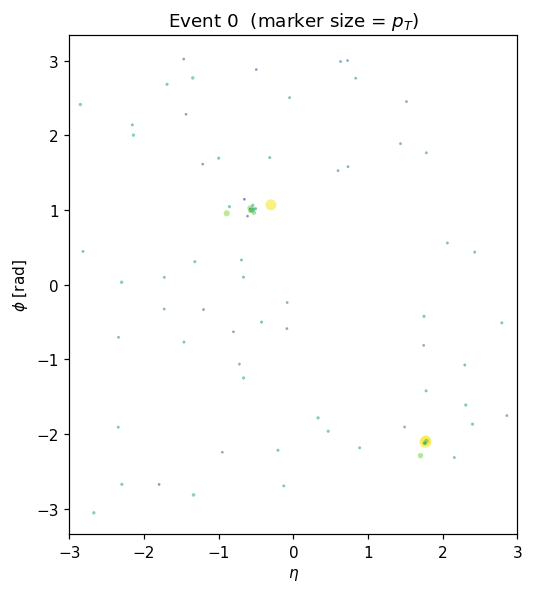

In [6]:
def plot_event(ev, ax=None, title=None):
    """한 이벤트의 입자를 eta-phi 평면에 그린다. 점 크기 = pT."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5.5))
    e = ak.to_numpy(arrays["Particle_eta"][ev])
    p = ak.to_numpy(arrays["Particle_phi"][ev])
    t = ak.to_numpy(arrays["Particle_pt"][ev])

    ax.scatter(e, p, s=3 + t * 1.2, alpha=0.55,
               c=t, cmap="viridis", norm="log", edgecolors="none")
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\phi$ [rad]")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    # 축 비율을 1:1 로 맞춘다. 안 그러면 R=0.4 원이 타원으로 보여 거리 감각이 틀어진다.
    ax.set_aspect("equal")
    ax.set_title(title or f"Event {ev}  (marker size = $p_T$)")
    return ax

plt.rcParams["figure.dpi"] = 110
ax = plot_event(0)
plt.tight_layout()
plt.show()

**큰 점 두 뭉치가 보이는가?**

그게 jet 이다. 정확히 말하면 — 충돌에서 튀어나온 쿼크나 글루온은 **혼자 존재할 수 없어서**
(색가둠, color confinement) 즉시 여러 개의 강입자(hadron)로 쪼개진다.
그 조각들은 원래 쿼크가 가던 방향으로 다발을 이루어 날아간다.

검출기가 보는 것은 그 **다발**이지 쿼크가 아니다. 그 다발을 jet 이라 부른다.

작은 점들이 배경처럼 흩어져 있는 것은 같은 충돌에서 나온 부드러운 활동(underlying event)이다.

## 4. 뭉침을 알고리즘으로 찾기 = 클러스터링

눈으로는 보이지만, 수백만 이벤트를 사람이 볼 수는 없다. 규칙이 필요하다.

가장 널리 쓰이는 규칙이 **anti-kT 알고리즘**이다. 아이디어는 간단하다:

1. 가장 pT 가 큰 입자에서 시작한다
2. 그 주변 반경 `R` 안의 입자를 흡수한다
3. 더 흡수할 게 없으면 그 뭉치를 jet 하나로 확정한다
4. 남은 입자로 반복한다

`R` 은 우리가 정하는 값이다. LHC 에서는 보통 **R = 0.4** 를 쓴다.
(여기서 거리는 `ΔR = √(Δη² + Δφ²)`)

anti-kT 가 표준이 된 이유는 **결과가 안정적**이기 때문이다. 부드러운 입자를 하나 더하거나
빼도 jet 이 크게 변하지 않는다 (IRC safety). 이론 계산과 비교하려면 이 성질이 필수다.

In [7]:
R = 0.4

# fastjet 에 넘길 4-벡터를 만든다.
#
# ⚠️ 주의: 여기에는 pt/eta/phi/mass 네 개만 넣어야 한다.
#    charge 같은 필드를 함께 넘기면 fastjet 이 조용히 틀린 결과를 낸다
#    (경고도 예외도 없다 — 이 프로젝트에서 실제로 겪었다. docs/WORKFLOW.md 참고)
particles = ak.zip({
    "pt":   arrays["Particle_pt"],
    "eta":  arrays["Particle_eta"],
    "phi":  arrays["Particle_phi"],
    "mass": arrays["Particle_mass"],
}, with_name="Momentum4D")

jetdef = fastjet.JetDefinition(fastjet.antikt_algorithm, R)
seq = fastjet.ClusterSequence(particles, jetdef)

# pT 20 GeV 이상인 jet 만 남긴다 (그 아래는 배경이 대부분)
jets = seq.inclusive_jets(min_pt=20)
constituents = seq.constituents(min_pt=20)

print("이벤트별 jet 개수 (앞 10개):", ak.to_list(ak.num(jets))[:10])

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


이벤트별 jet 개수 (앞 10개): [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


## 5. 찾은 jet 을 그림 위에 겹쳐 그리기

같은 이벤트에 jet 의 위치와 반경 R 을 원으로 표시해보자.

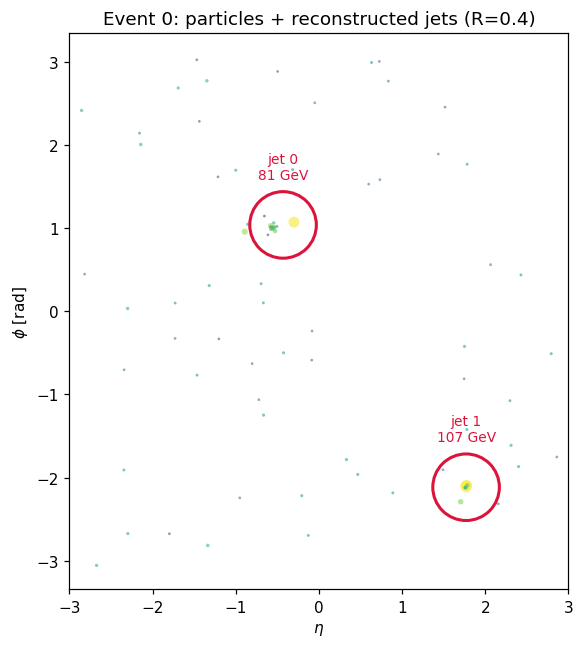

In [8]:
def plot_event_with_jets(ev):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plot_event(ev, ax=ax, title=f"Event {ev}: particles + reconstructed jets (R={R})")

    for i in range(len(jets[ev])):
        je, jp, jpt = jets[ev][i].eta, jets[ev][i].phi, jets[ev][i].pt
        circle = plt.Circle((je, jp), R, fill=False, color="crimson", lw=2)
        ax.add_patch(circle)
        ax.text(je, jp + R + 0.15, f"jet {i}\n{jpt:.0f} GeV",
                ha="center", color="crimson", fontsize=9)
    return fig

fig = plot_event_with_jets(0)
plt.tight_layout()
plt.show()

빨간 원이 알고리즘이 찾아낸 jet 이다. 눈으로 본 뭉침과 일치한다.

여기서 중요한 점 하나: **jet 은 자연에 있는 물체가 아니라 우리가 정의한 것이다.**
R 을 바꾸면 jet 도 바뀐다. 그래서 논문에는 항상 "anti-kT, R=0.4" 처럼 정의를 명시한다.
정의를 안 밝힌 jet 측정값은 의미가 없다.

## 6. jet 하나를 열어보기

jet 은 입자들의 모음이다. 실제로 그런지 확인하자.

In [9]:
ev, ij = 0, 0
jet = jets[ev][ij]
cons = constituents[ev][ij]

print(f"이벤트 {ev}, jet {ij}")
print(f"  jet pT   : {jet.pt:.2f} GeV")
print(f"  jet eta  : {jet.eta:.3f}")
print(f"  jet phi  : {jet.phi:.3f}")
print(f"  구성 입자 수: {len(cons)}")
print()

# jet 의 4-벡터는 구성 입자 4-벡터의 합이다. 확인해보자.
total = ak.zip({
    "px": ak.sum(cons.px), "py": ak.sum(cons.py),
    "pz": ak.sum(cons.pz), "E":  ak.sum(cons.E),
}, with_name="Momentum4D")

print(f"  구성 입자 4-벡터 합의 pT : {total.pt:.2f} GeV")
print(f"  차이                     : {abs(total.pt - jet.pt):.2e} GeV  <- 0 이어야 정상")

이벤트 0, jet 0
  jet pT   : 80.56 GeV
  jet eta  : -0.431
  jet phi  : 1.037
  구성 입자 수: 17

  구성 입자 4-벡터 합의 pT : 80.56 GeV
  차이                     : 0.00e+00 GeV  <- 0 이어야 정상


In [10]:
# 구성 입자 중 pT 가 큰 것부터 몇 개
order = ak.argsort(cons.pt, ascending=False)
print(f"{'#':>3} {'pT [GeV]':>10} {'jet 대비 비율':>14} {'jet 축과의 거리 dR':>20}")
for n, i in enumerate(order[:8]):
    ci = cons[i]
    dphi = (ci.phi - jet.phi + np.pi) % (2 * np.pi) - np.pi
    dr = np.sqrt((ci.eta - jet.eta) ** 2 + dphi ** 2)
    print(f"{n:>3} {ci.pt:>10.2f} {ci.pt / jet.pt:>14.3f} {dr:>20.3f}")
print()
print(f"모든 구성 입자의 dR 이 {R} 보다 작다:", bool(ak.all(
    np.sqrt((cons.eta - jet.eta)**2 +
            (((cons.phi - jet.phi + np.pi) % (2*np.pi)) - np.pi)**2) < R)))

  #   pT [GeV]      jet 대비 비율        jet 축과의 거리 dR
  0      40.71          0.505                0.135
  1       9.07          0.113                0.148
  2       8.13          0.101                0.134
  3       4.88          0.061                0.120
  4       4.14          0.051                0.124
  5       3.32          0.041                0.154
  6       2.45          0.030                0.138
  7       2.43          0.030                0.127

모든 구성 입자의 dR 이 0.4 보다 작다: True


보다시피 jet 은 **소수의 강한 입자 + 다수의 약한 입자**로 이루어진다.
그리고 모든 구성 입자는 jet 축에서 R 안에 있다 — 알고리즘이 그렇게 모았으니 당연하다.

`jet pT = 구성 입자 4-벡터 합` 이 정확히 성립하는 것도 확인했다.
이런 **닫힘 검사(closure test)** 는 습관을 들이는 게 좋다. 앞서 언급한 fastjet 함정도
이 검사로 잡아냈다.

## 7. 여러 이벤트를 모아서 보기

이제 이벤트 하나가 아니라 전체를 본다. 물리 측정은 항상 **통계**다.

전체 jet 개수: 434


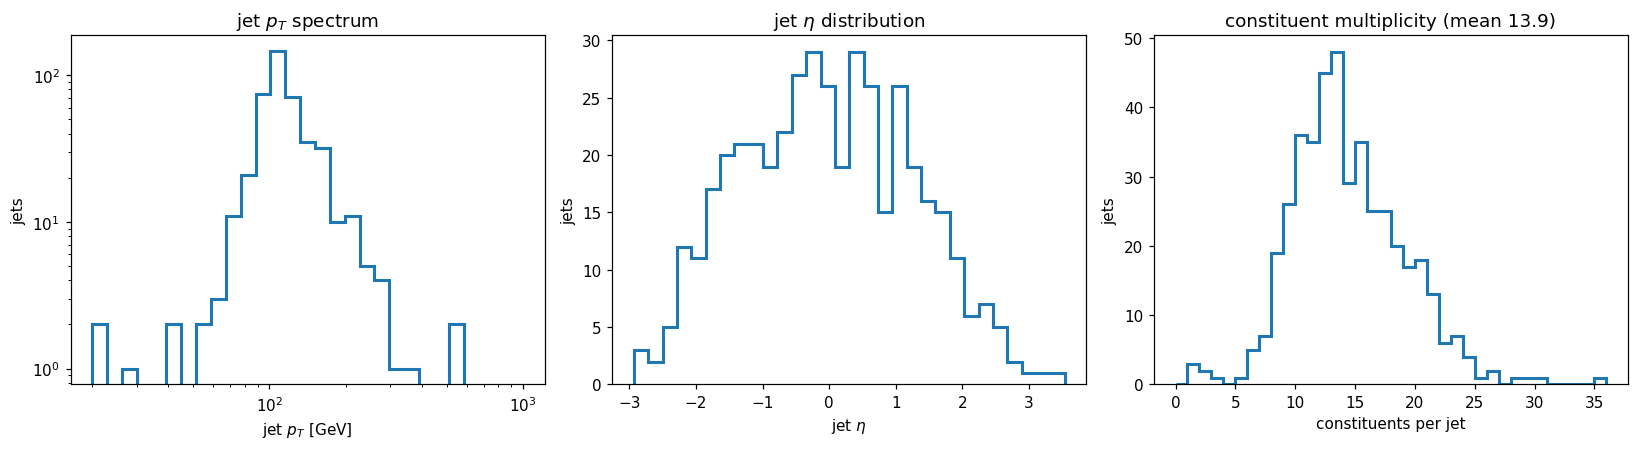

In [11]:
jets_flat = ak.flatten(jets)          # 모든 이벤트의 jet 을 한 줄로
cons_flat = ak.flatten(constituents, axis=1)

print("전체 jet 개수:", len(jets_flat))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) jet pT 스펙트럼 — 가장 기본적인 QCD 측정
ax = axes[0]
bins = np.logspace(np.log10(20), np.log10(1000), 30)
ax.hist(ak.to_numpy(jets_flat.pt), bins=bins, histtype="step", lw=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"jet $p_T$ [GeV]"); ax.set_ylabel("jets")
ax.set_title("jet $p_T$ spectrum")

# (2) jet 이 하늘 어디에 생기나
ax = axes[1]
ax.hist(ak.to_numpy(jets_flat.eta), bins=30, histtype="step", lw=2)
ax.set_xlabel(r"jet $\eta$"); ax.set_ylabel("jets")
ax.set_title(r"jet $\eta$ distribution")

# (3) jet 하나에 입자가 몇 개나
ax = axes[2]
nc = ak.to_numpy(ak.num(cons_flat))
ax.hist(nc, bins=range(0, nc.max() + 2), histtype="step", lw=2)
ax.set_xlabel("constituents per jet"); ax.set_ylabel("jets")
ax.set_title(f"constituent multiplicity (mean {nc.mean():.1f})")

plt.tight_layout()
plt.show()

**jet pT 스펙트럼이 급격히 떨어지는 것**에 주목하자. 로그–로그 축에서 거의 직선인데,
이는 멱함수 꼴 `dN/dpT ~ pT^(-n)` 이라는 뜻이다.

이유는 간단하다. pT 가 큰 jet 을 만들려면 양성자 안의 쿼크/글루온이 큰 운동량을 가져야 하는데,
그럴 확률이 급격히 작아진다. 이 기울기 자체가 QCD 와 양성자 구조에 대한 정보다.

실제 분석에서 이 스펙트럼은 **가장 먼저 하는 측정**이다.
이론 예측과 비교할 수 있고, 검출기가 제대로 작동하는지 확인하는 기준도 된다.

## 8. 정리 — 우리가 한 것

1. ROOT 파일을 `uproot` 로 열었다 (ROOT 프로그램 설치 없이)
2. 이벤트마다 입자 목록이 들어있는 구조를 확인했다
3. 입자를 η–φ 평면에 찍어 **뭉침을 눈으로 확인**했다
4. anti-kT (R=0.4) 로 그 뭉침을 jet 으로 잡아냈다
5. jet 이 입자들의 모음임을 닫힘 검사로 확인했다
6. 여러 이벤트를 모아 jet pT 스펙트럼을 그렸다

**핵심 개념 세 가지**

- jet 은 쿼크/글루온이 강입자 다발로 변한 결과다. 쿼크를 직접 볼 수는 없다.
- jet 은 **정의에 의존한다**. 알고리즘과 R 을 반드시 명시해야 한다.
- 물리는 이벤트 하나가 아니라 **분포**에서 나온다.

## 다음 단계

**진짜 데이터로 바꾸기.** 위 코드에서 바꿀 것은 사실상 `DATA` 경로와 변수 이름뿐이다.
[CERN Open Data](https://opendata.cern.ch/) 에서 파일을 받은 뒤,
1절의 "들어있는 변수(branch)" 출력을 먼저 확인하고 이름을 맞춰주면 된다.

실험마다 이름이 다르다 (CMS 는 `PFCands_*`, ATLAS 는 다른 이름). 그래서
**분석 전에 항상 branch 목록부터 찍어보는 것**이 습관이 되어야 한다.

이후 가능한 것들은 `docs/tier_physics_programme.md` 에 정리돼 있다.